## Exploratory Data Analysis

### 1. Project Objective

The purpose of this notebook is to explore the characteristics of the cleaned dataset before conducting business-focused analysis.

This notebook focuses on:

- Understanding variable distributions
- Identifying potential outliers
- Examining relationships between variables
- Recording initial observations

### 2. Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")


from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.loader import load_clean_data


### 3. Load Clean Dataset

In [3]:
df = load_clean_data("../data/processed/superstore_clean.csv")

df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Quantity,Discount,Profit,Year,Month,Month Name,Quarter,Weekday,Shipping Days,Profit Margin
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2,0.00,41.9136,2013,11,November,4,Saturday,3,0.1600
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,0.00,219.5820,2013,11,November,4,Saturday,3,0.3000
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.00,6.8714,2013,6,June,2,Thursday,4,0.4700
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,5,0.45,-383.0310,2012,10,October,4,Thursday,7,-0.4000
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2,0.20,2.5164,2012,10,October,4,Thursday,7,0.1125


### 4. Numerical Variables

#### 4.1 Distribution

##### Sales

<Axes: xlabel='Sales', ylabel='Count'>

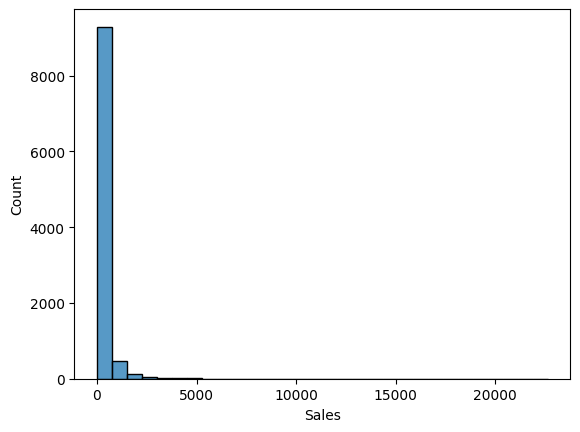

In [4]:
sns.histplot(df["Sales"], bins=30)

Sales is highly right-skewed.
Most orders have relatively small sales values.

##### Profit

<Axes: xlabel='Profit', ylabel='Count'>

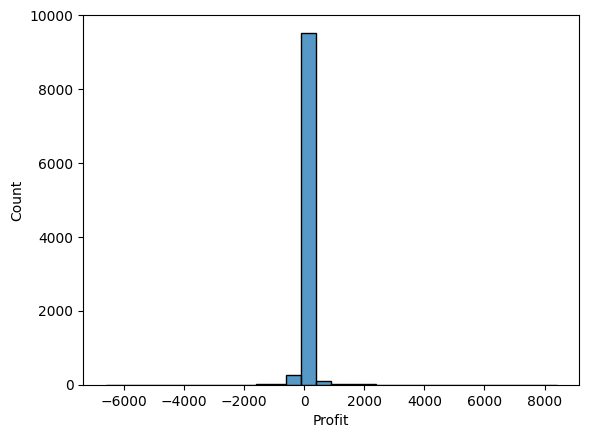

In [5]:
sns.histplot(df["Profit"], bins=30)

Profit contains both positive and negtive values.

##### Discount

<Axes: xlabel='Discount', ylabel='Count'>

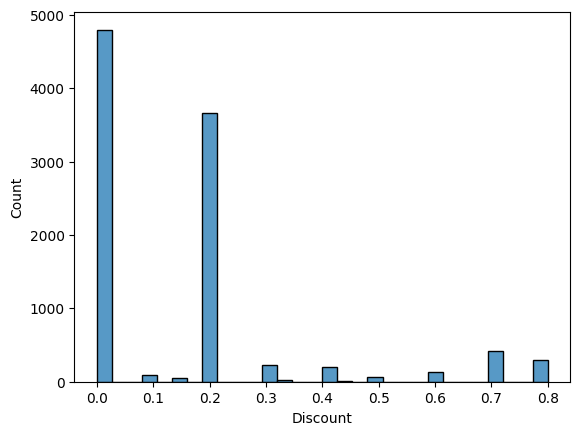

In [6]:
sns.histplot(df["Discount"], bins=30)

Discounts are concentrated on 0 and 0.2.

##### Quantity

<Axes: xlabel='Quantity', ylabel='Count'>

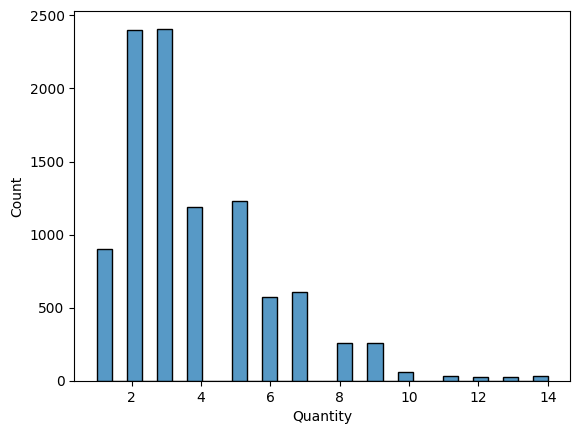

In [7]:
sns.histplot(df["Quantity"], bins=30)

An order typically contains 2 or 3 items.

##### Shipping Days

<Axes: xlabel='Shipping Days', ylabel='Count'>

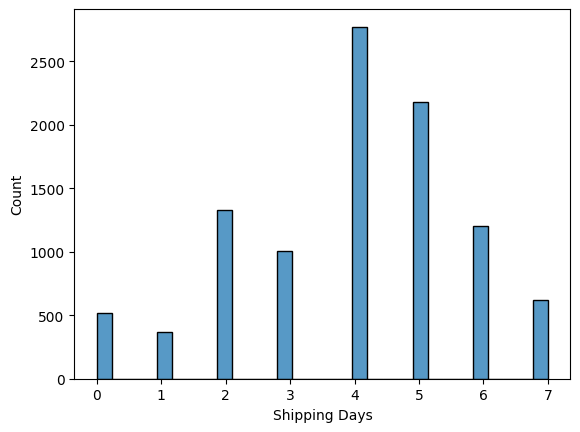

In [8]:
sns.histplot(df["Shipping Days"], bins=30)

The shipping days are mainly 4 or 5.

##### Profit Margin

<Axes: xlabel='Profit Margin', ylabel='Count'>

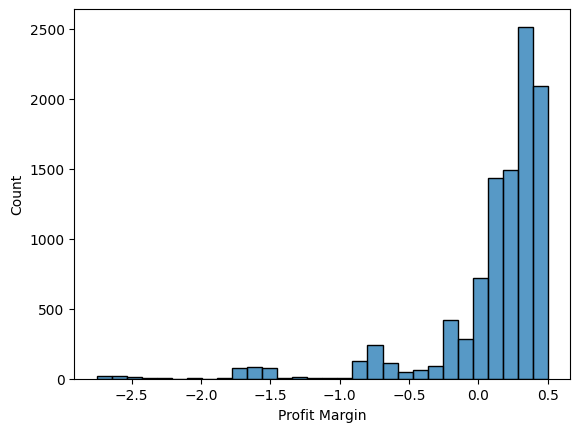

In [9]:
sns.histplot(df["Profit Margin"], bins=30)

There are particularly large negative profits.

#### 4.2 Summary Statistics

In [10]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Row ID,9994.0,4997.5,1.0,2499.25,4997.5,7495.75,9994.0,2885.163629
Order Date,9994,2013-04-30 19:20:02.401441024,2011-01-04 00:00:00,2012-05-23 00:00:00,2013-06-27 00:00:00,2014-05-15 00:00:00,2014-12-31 00:00:00,NaN
Ship Date,9994,2013-05-04 18:20:49.229537792,2011-01-08 00:00:00,2012-05-27 00:00:00,2013-06-30 00:00:00,2014-05-19 00:00:00,2015-01-06 00:00:00,NaN
Sales,9994.0,229.858001,0.444,17.28,54.49,209.94,22638.48,623.245101
Quantity,9994.0,3.789574,1.0,2.0,3.0,5.0,14.0,2.22511
Discount,9994.0,0.156203,0.0,0.0,0.2,0.2,0.8,0.206452
Profit,9994.0,28.656896,-6599.978,1.72875,8.6665,29.364,8399.976,234.260108
Year,9994.0,2012.722934,2011.0,2012.0,2013.0,2014.0,2014.0,1.124039
Month,9994.0,7.814589,1.0,5.0,9.0,11.0,12.0,3.286047
Quarter,9994.0,2.88413,1.0,2.0,3.0,4.0,4.0,1.056771


#### 4.3 Outlier Detection

##### Sales

<Axes: xlabel='Sales'>

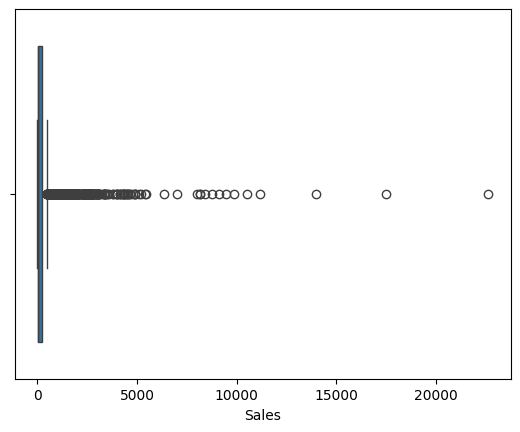

In [11]:
sns.boxplot(x=df["Sales"])

Sales contains several extreme values.

##### Profit

<Axes: xlabel='Profit'>

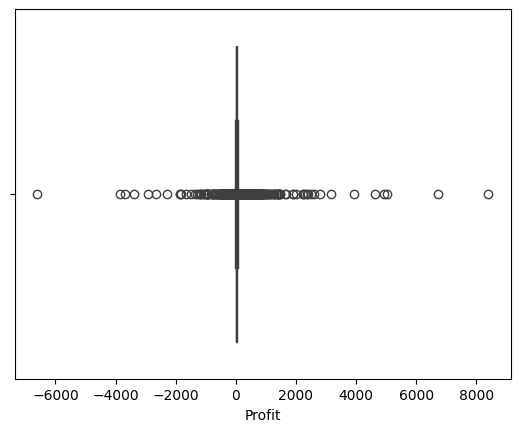

In [12]:
sns.boxplot(x=df["Profit"])

##### Quantity

<Axes: xlabel='Quantity'>

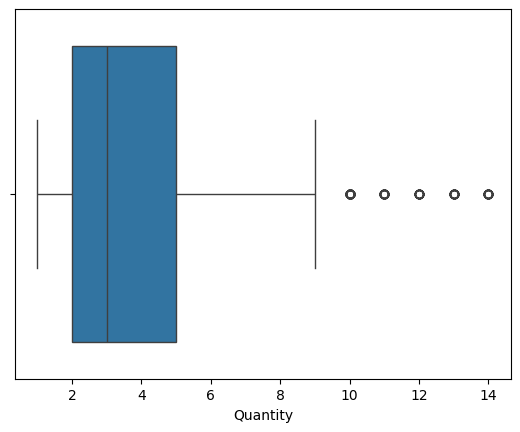

In [13]:
sns.boxplot(x=df["Quantity"])

### 5. Categorical Variables

#### 5.1 Frequency Distribution

##### Segment

In [ ]:
# Frequency Table
segment_counts = (
    df["Segment"]
    .value_counts()
    .rename_axis("Segment")
    .reset_index(name="Count")
)

segment_counts

,Segment,Count
0,Consumer,5191
1,Corporate,3020
2,Home Office,1783


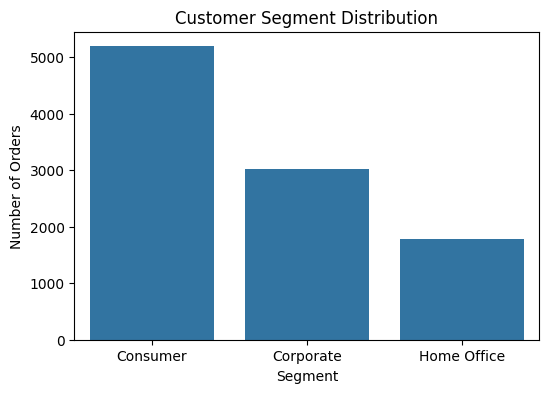

In [17]:
# Bar Chart
plt.figure(figsize=(6,4))

sns.barplot(
    data=segment_counts,
    x="Segment",
    y="Count"
)

plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Orders")

plt.show()

• Consumer is the largest customer segment.<br>
• Home Office has the fewest orders.

##### Category

In [18]:
category_counts = (
    df["Category"]
    .value_counts()
    .rename_axis("Category")
    .reset_index(name="Count")
)

category_counts

,Category,Count
0,Office Supplies,6026
1,Furniture,2121
2,Technology,1847


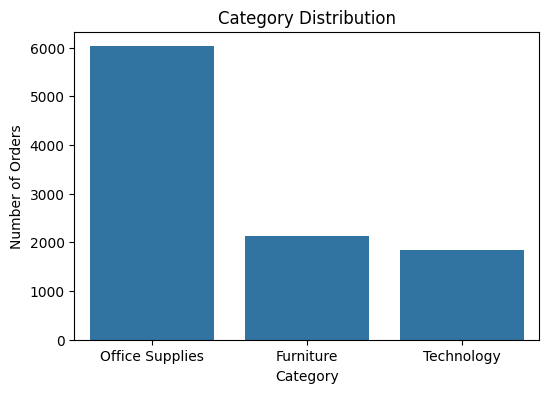

In [19]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=category_counts,
    x="Category",
    y="Count"
)

plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Orders")

plt.show()

Office Supplies appears most frequently, while Technology has the fewest order records.

##### Sub-Category

<Axes: xlabel='Sub-Category'>

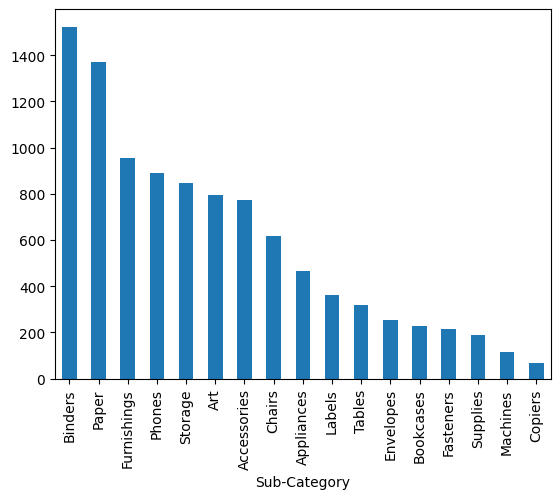

In [16]:
df["Sub-Category"].value_counts().plot.bar()